# Métricas deterministas para respuestas

## Objetivos

Al terminar podrás construir un *eval set*, distinguir métrica, evaluación y veredicto, y calcular exact match, JSON válido, precision, recall, F1, BLEU, ROUGE y perplejidad. Las fórmulas son deterministas; los candidatos se generan en vivo con Gemini para evaluar un LLM real, no respuestas inventadas.

## 1. Métrica, evaluación y veredicto

Una **métrica** es un número (por ejemplo, F1). Una **evaluación** aplica varias métricas sobre casos versionados. Un **veredicto** transforma esos resultados en una decisión: conservar, corregir o descartar una versión. El benchmark sirve para elegir; el eval set propio responde si nuestro sistema funciona.

El conjunto dorado siguiente contiene preguntas, referencias y contratos esperados. No contiene respuestas candidatas: las genera Qwen en la siguiente celda y se conservan en memoria para que todos los resultados provengan de una ejecución real.

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv

from metrics_course.datasets import load_ticket_cases
from metrics_course.gemini_generation import generate_ticket_predictions

load_dotenv()

cases = load_ticket_cases()
gold_set = pd.DataFrame(cases)

gold_set[["id", "category", "question", "reference_answer", "expected_decision", "evidence"]]

,id,category,question,reference_answer,expected_decision,evidence
0,T01,status,"¿Cuál es el estado, prioridad y problema del t...","TK-1042 está abierto, tiene prioridad media y ...",report_status,"{'ticket_id': 'TK-1042', 'store_id': 'POL-01',..."
1,T02,schedule,¿Qué visita tiene programada el ticket TK-1043...,TK-1043 tiene una visita programada para el 16...,report_schedule,"{'ticket_id': 'TK-1043', 'store_id': 'POL-01',..."
2,T03,priority,¿Cuál es la prioridad y el estado del ticket T...,TK-2001 tiene prioridad alta y está en progreso.,report_priority,"{'ticket_id': 'TK-2001', 'store_id': 'CON-02',..."
3,T04,not_found,¿Cuál es el estado del ticket TK-9999?,No encontré el ticket TK-9999 en el sistema.,report_not_found,"{'ticket_id': 'TK-9999', 'found': False}"
4,T05,json,Devuelve un resumen JSON del ticket TK-1042.,TK-1042 está abierto y tiene prioridad media.,json_summary,"{'ticket_id': 'TK-1042', 'status': 'open', 'pr..."


## 2. Generar predicciones reales con Gemini

Gemini responde cada caso con un contrato JSON y recibe únicamente la evidencia mostrada en el eval set. Los registros corresponden a los tickets semilla del proyecto de agentes (`TK-1042`, `TK-1043` y `TK-2001`); por tanto, puedes corroborar cada campo contra `agents/src/ticket_agents/database.py`. Esta celda requiere `GOOGLE_API_KEY` en `.env` y sí consume llamadas reales. Guarda el resultado si quieres comparar versiones: el eval set dorado no se modifica.

In [2]:
model = os.getenv('METRICS_GENERATION_MODEL', 'gemini-2.5-flash')
tickets = generate_ticket_predictions(cases, model=model)
tickets[['id', 'model', 'question', 'candidate_answer', 'predicted_decision', 'raw_response', 'latency_seconds']]


,id,model,question,candidate_answer,predicted_decision,raw_response,latency_seconds
0,T01,gemini-3.1-flash-lite,"¿Cuál es el estado, prioridad y problema del t...",El ticket TK-1042 se encuentra en estado abier...,json_summary,"{\n ""answer"": ""El ticket TK-1042 se encuentra...",1.168016
1,T02,gemini-3.1-flash-lite,¿Qué visita tiene programada el ticket TK-1043...,El ticket TK-1043 tiene programada una visita ...,report_schedule,"{\n ""answer"": ""El ticket TK-1043 tiene progra...",0.881077
2,T03,gemini-3.1-flash-lite,¿Cuál es la prioridad y el estado del ticket T...,El ticket TK-2001 tiene una prioridad alta y s...,json_summary,"{\n ""answer"": ""El ticket TK-2001 tiene una pr...",0.811936
3,T04,gemini-3.1-flash-lite,¿Cuál es el estado del ticket TK-9999?,"Lo siento, no se ha encontrado información sob...",report_not_found,"{\n ""answer"": ""Lo siento, no se ha encontrado...",0.795860
4,T05,gemini-3.1-flash-lite,Devuelve un resumen JSON del ticket TK-1042.,"El ticket TK-1042 se encuentra abierto, tiene ...",json_summary,"{\n ""answer"": ""El ticket TK-1042 se encuentra...",0.866683


In [3]:
ticket = tickets.iloc[0]
print("Elementos del primer ticket:")
print(f"ID: {ticket['id']}")
print(f"Modelo: {ticket['model']}")
print(f"Pregunta: {ticket['question']}")
print(f"Respuesta candidata: {ticket['candidate_answer']}")
print(f"Decisión predicha: {ticket['predicted_decision']}")
print(f"Respuesta cruda: {ticket['raw_response']}")
print(f"Latencia (segundos): {ticket['latency_seconds']:.3f}")

Elementos del primer ticket:
ID: T01
Modelo: gemini-3.1-flash-lite
Pregunta: ¿Cuál es el estado, prioridad y problema del ticket TK-1042?
Respuesta candidata: El ticket TK-1042 se encuentra en estado abierto, tiene una prioridad media y el problema reportado es una falla eléctrica en el tablero.
Decisión predicha: json_summary
Respuesta cruda: {
  "answer": "El ticket TK-1042 se encuentra en estado abierto, tiene una prioridad media y el problema reportado es una falla eléctrica en el tablero.",
  "decision": "json_summary",
  "tool_calls": [
    "get_ticket"
  ],
  "arguments": {
    "ticket_id": "TK-1042"
  },
  "structured_output": {
    "ticket_id": "TK-1042",
    "status": "open",
    "priority": "medium",
    "problem": "Tablero eléctrico sin energía"
  }
}
Latencia (segundos): 1.168


## 3. Exact match y formatos estructurados

Comparar texto literal sin normalizar es frágil: mayúsculas, acentos o puntuación no suelen cambiar el significado. Normalizamos sólo diferencias superficiales y después comparamos. Para salidas JSON, primero validamos que el texto se pueda parsear; un texto que parece JSON pero no lo es debe fallar.

In [4]:
from metrics_course.deterministic import exact_match, is_valid_json, json_exact_match

tickets['answer_exact_match'] = tickets.apply(
    lambda row: exact_match(row.candidate_answer, row.reference_answer), axis=1
)
tickets['json_valid'] = tickets.candidate_json.map(is_valid_json)
tickets['json_exact_match'] = tickets.apply(
    lambda row: json_exact_match(row.candidate_json, row.reference_json), axis=1
)
tickets[['id', 'answer_exact_match', 'json_valid', 'json_exact_match']]


,id,answer_exact_match,json_valid,json_exact_match
0,T01,0.0,True,0.0
1,T02,0.0,True,1.0
2,T03,0.0,True,0.0
3,T04,0.0,True,1.0
4,T05,0.0,True,0.0


**Interpretación.** Exact match es apropiado para IDs, acciones o contratos JSON. Es demasiado estricto para una explicación libre: dos respuestas equivalentes pueden usar palabras distintas.

## 4. Precision, recall, F1 y matriz de confusión

Aquí clasificamos la **decisión** que propuso el LLM contra la decisión dorada. Precision pregunta: *de las decisiones predichas, cuántas eran correctas*. Recall pregunta: *de las decisiones esperadas, cuántas detectamos*. F1 equilibra ambas. Antes de optimizar, hay que declarar qué error cuesta más: aprobar una acción peligrosa o rechazar una respuesta correcta.

{'precision': 0.467, 'recall': 0.6, 'f1': 0.5}


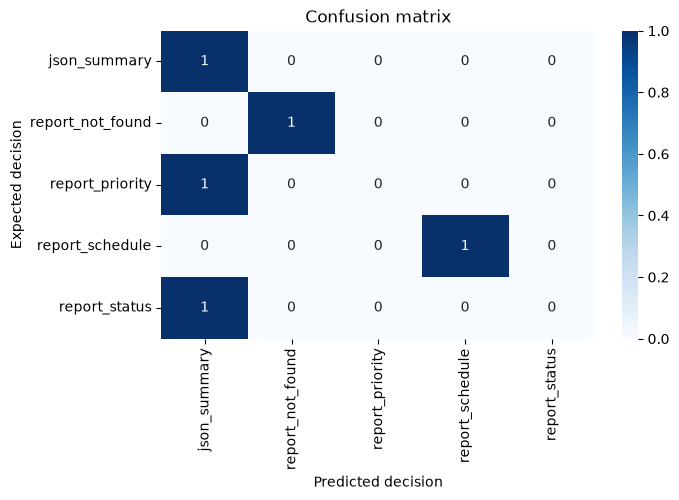

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from metrics_course.deterministic import classification_scores

scores = classification_scores(tickets.expected_decision, tickets.predicted_decision)
print({key: round(scores[key], 3) for key in ['precision', 'recall', 'f1']})

plt.figure(figsize=(7, 4))
sns.heatmap(scores['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=scores['labels'], yticklabels=scores['labels'])
plt.xlabel('Predicted decision')
plt.ylabel('Expected decision')
plt.title('Confusion matrix')
plt.show()


## 4. Contratos de herramientas

En sistemas con herramientas, una respuesta bien escrita no basta. Evaluamos por separado: herramienta correcta, argumentos correctos y secuencia correcta. Así sabemos si el error está en la decisión del agente o en la redacción final.

In [6]:
from metrics_course.deterministic import arguments_match, tool_sequence_match

tickets['tool_sequence_match'] = tickets.apply(
    lambda row: tool_sequence_match(row.expected_tools, row.actual_tools), axis=1
)
tickets['arguments_match'] = tickets.apply(
    lambda row: arguments_match(row.expected_arguments, row.actual_arguments), axis=1
)
tickets[['id', 'tool_sequence_match', 'arguments_match']]


,id,tool_sequence_match,arguments_match
0,T01,1.0,1.0
1,T02,1.0,1.0
2,T03,1.0,1.0
3,T04,1.0,1.0
4,T05,1.0,1.0


## 5. BLEU y ROUGE

BLEU mide precisión de n-gramas contra una referencia; ROUGE mide cobertura de n-gramas y es habitual en resumen. Son rápidos y reproducibles, pero no reconocen bien la misma idea escrita con palabras distintas. Úsalos para comparar variantes similares y nunca como único veredicto para lenguaje abierto.

In [7]:
from metrics_course.deterministic import bleu_score, rouge_scores

example = tickets.iloc[0]
print("Comparando la respuesta generada con la referencia:")
print(f"- Generada:\n{example.candidate_answer}\n")
print(f"- Referencia:\n{example.reference_answer}\n")

bleu = round(bleu_score(example.candidate_answer, example.reference_answer), 3)
rouge = {key: round(value, 3) for key, value in rouge_scores(example.candidate_answer, example.reference_answer).items()}

print(f"BLEU obtenido: {bleu} (mide coincidencia exacta de frases, sensible a cambios mínimos)")
print(f"ROUGE obtenido: {rouge} (mide cobertura de n-gramas: qué tanto de la referencia aparece en la respuesta generada)")


Comparando la respuesta generada con la referencia:
- Generada:
El ticket TK-1042 se encuentra en estado abierto, tiene una prioridad media y el problema reportado es una falla eléctrica en el tablero.

- Referencia:
TK-1042 está abierto, tiene prioridad media y reporta un tablero eléctrico sin energía.

BLEU obtenido: 0.104 (mide coincidencia exacta de frases, sensible a cambios mínimos)
ROUGE obtenido: {'rouge1': 0.439, 'rouge2': 0.205, 'rougeL': 0.39} (mide cobertura de n-gramas: qué tanto de la referencia aparece en la respuesta generada)


In [8]:
# Calcular BLEU y ROUGE promedio para todas las respuestas
bleu_scores = tickets.apply(
    lambda row: bleu_score(row.candidate_answer, row.reference_answer), axis=1
)
rouge_all = tickets.apply(
    lambda row: rouge_scores(row.candidate_answer, row.reference_answer), axis=1, result_type='expand'
)

import pandas as pd

bleu_mean = round(bleu_scores.mean(), 3)
rouge_means = {key: round(rouge_all[key].mean(), 3) for key in rouge_all.columns}

metrics_table = pd.DataFrame(
    {
        "BLEU promedio": [bleu_mean],
        **{f"ROUGE {key} promedio": [value] for key, value in rouge_means.items()}
    }
)
display(metrics_table)

,BLEU promedio,ROUGE rouge1 promedio,ROUGE rouge2 promedio,ROUGE rougeL promedio
0,0.123,0.591,0.287,0.536


## 6. Perplejidad con Qwen local en Ollama

La perplejidad requiere probabilidades por token, no necesariamente un modelo descargado mediante Transformers. Ollama devuelve `logprobs` de los tokens generados. Para cada token calculamos `probability = exp(logprob)`; después, la perplejidad es `exp(-promedio(logprob))`.

Una probabilidad alta indica que el modelo esperaba ese token dado el texto anterior. Si muchos tokens tienen probabilidad baja, el promedio de logprobs baja y la perplejidad sube. Esta es la perplejidad de una continuación generada de manera determinista, no la evaluación *teacher-forced* de una referencia arbitraria.

El modelo de este laboratorio es `qwen:0.5b`, ligero y suficiente para hacer visible el cálculo. Confirma que Ollama esté activo antes de ejecutar la celda.

In [9]:
import os
from dotenv import load_dotenv
from metrics_course.perplexity import generated_perplexity, perplexity_summary, token_probability_table

load_dotenv()
model = os.getenv('OLLAMA_MODEL', 'qwen:0.5b')
host = os.getenv('OLLAMA_HOST', 'http://127.0.0.1:11434')

# La perplejidad se calcula promediando los logprobs de los tokens generados y aplicando exp(-mean(logprobs))
prompt = 'El estado del ticket TK-1042 es'
result = generated_perplexity(
    prompt=prompt,
    model=model,
    host=host,
    max_tokens=24,
)

print(f"Prompt usado: {prompt}")
print('Modelo:', result['model'])
print('Respuesta generada:', result['response'])
summary = perplexity_summary(result['token_details'])
print('Perplejidad promedio:', round(summary['perplexity'], 3))
print('Probabilidad geométrica promedio:', f"{summary['geometric_mean_probability']:.1%}")
print('Interpretación: equivale a elegir, en promedio, entre', round(summary['perplexity'], 1), 'alternativas igualmente probables.')

token_table = token_probability_table(result['token_details'])
doubt_columns = ['position', 'token', 'probability', 'surprisal', 'best_alternative', 'best_alternative_probability', 'alternative_margin']
doubt_tokens = token_table.sort_values('surprisal', ascending=False).head(6)
print('\nTokens que más elevan la perplejidad (mayor sorpresa):')
display(doubt_tokens[doubt_columns].style.format({
    'probability': '{:.1%}', 'surprisal': '{:.3f}',
    'best_alternative_probability': '{:.1%}', 'alternative_margin': '{:+.1%}'
}).background_gradient(subset=['surprisal'], cmap='Reds'))

display(token_table.style.format({
    'logprob': '{:.3f}', 'probability': '{:.1%}', 'surprisal': '{:.3f}',
    'best_alternative_probability': '{:.1%}', 'alternative_margin': '{:+.1%}'
}))


Prompt usado: El estado del ticket TK-1042 es
Modelo: qwen:0.5b
Respuesta generada:  el estado de la ciudad de San José, en California.
Perplejidad promedio: 3.897
Probabilidad geométrica promedio: 25.7%
Interpretación: equivale a elegir, en promedio, entre 3.9 alternativas igualmente probables.

Tokens que más elevan la perplejidad (mayor sorpresa):


,position,token,probability,surprisal,best_alternative,best_alternative_probability,alternative_margin
4,5,' ciudad',5.1%,2.968,' California',4.3%,-0.9%
3,4,' la',7.7%,2.563,' México',4.7%,-3.0%
6,7,' San',7.8%,2.556,' Santa',3.2%,-4.6%
10,11,' California',18.1%,1.711,' el',19.7%,+1.6%
2,3,' de',22.8%,1.479,' del',66.6%,+43.8%
0,1,' el',25.0%,1.385,':\n\n',6.9%,-18.1%


,position,token,logprob,probability,surprisal,best_alternative,best_alternative_probability,alternative_margin,top_alternatives
0,1,' el',-1.385,25.0%,1.385,':\n\n',6.9%,-18.1%,"' el': 0.250, ':\n\n': 0.069, ':\n': 0.049"
1,2,' estado',-0.032,96.9%,0.032,'州',0.4%,-96.5%,"' estado': 0.969, '州': 0.004, ' Estado': 0.001"
2,3,' de',-1.479,22.8%,1.479,' del',66.6%,+43.8%,"' del': 0.666, ' de': 0.228, ' que': 0.014"
3,4,' la',-2.563,7.7%,2.563,' México',4.7%,-3.0%,"' la': 0.077, ' México': 0.047, ' Texas': 0.021"
4,5,' ciudad',-2.968,5.1%,2.968,' California',4.3%,-0.9%,"' ciudad': 0.051, ' California': 0.043, ' Ti': 0.028"
5,6,' de',-0.041,96.0%,0.041,"','",0.7%,-95.3%,"' de': 0.960, ',': 0.007, ' del': 0.002"
6,7,' San',-2.556,7.8%,2.556,' Santa',3.2%,-4.6%,"' San': 0.078, ' Santa': 0.032, ' Madrid': 0.030"
7,8,' José',-1.338,26.2%,1.338,' Francisco',26.1%,-0.1%,"' José': 0.262, ' Francisco': 0.261, ' Juan': 0.051"
8,9,"','",-1.183,30.6%,1.183,' en',30.4%,-0.2%,"',': 0.306, ' en': 0.304, '.': 0.304"
9,10,' en',-0.738,47.8%,0.738,' California',11.2%,-36.6%,"' en': 0.478, ' California': 0.112, ' México': 0.037"


**Cómo leer la duda.** `surprisal = -logprob`: mientras más alto, más sorprendió al modelo el token que terminó generando. `best_alternative` y `alternative_margin` revelan si otra opción conocida por el modelo era más probable; un margen positivo significa que la elección generada no era su alternativa favorita.

Para una perplejidad de `3.897`, la probabilidad geométrica promedio es `1 / 3.897 = 25.7%`. Es una forma de decir: a lo largo de la continuación, el modelo se comportó aproximadamente como si tuviera 3.897 opciones equiprobables por token. No es el promedio aritmético de la columna `probability`.

## Resumen y ejercicios

| Métrica | Sirve para | No basta para |
|---|---|---|
| Exact match / JSON | Contratos y campos | Misma idea con palabras distintas |
| Precision, recall, F1 | Decisiones con etiquetas | Calidad de redacción |
| BLEU / ROUGE | Variantes cercanas a una referencia | Significado profundo |
| Perplejidad | Fluidez según un modelo | Utilidad o veracidad |

1. Cambia una respuesta sólo con puntuación y observa la normalización.
2. Define cuál error es más costoso para `T03` y qué métrica priorizarías.
3. Ejecuta Qwen con dos prompts cortos y compara sus perplejidades sin confundirlas con calidad factual.